<a href="https://www.kaggle.com/code/nicapotato/student-ai-dependency-burnout-eda?scriptVersionId=319337484" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# AI dependency, career anxiety, and student burnout — EDA

Dataset: [sridipbasu/ai-depndency-career-anxiety-and-student-burnout](https://www.kaggle.com/datasets/sridipbasu/ai-depndency-career-anxiety-and-student-burnout) (CSV: `ai_dependency_career_anxiety_students.csv`).


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import kagglehub
from IPython.display import display

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (11, 5)

CSV_BASENAME = "ai_dependency_career_anxiety_students.csv"
KAGGLE_SLUG = "sridipbasu/ai-depndency-career-anxiety-and-student-burnout"

EXPECTED_COLS = ["student_id", "age", "gender", "degree_type", "stream", "year_of_study", "college_tier", "urban_or_rural", "daily_ai_tool_usage_hrs", "primary_ai_tools_used", "uses_ai_for_assignments", "ai_replaces_own_thinking_score", "ai_dependency_score", "placement_anxiety_score", "fear_of_job_loss_to_ai", "career_clarity_score", "internship_experience", "weekly_job_application_count", "resume_confidence_score", "interview_anxiety_score", "daily_study_hours", "self_learning_hours_per_week", "skill_development_courses_taken", "social_media_hrs_per_day", "sleep_hours", "stress_level", "burnout_score", "motivation_score", "seeks_career_counseling", "overall_career_readiness_score"]


def resolve_csv_path() -> Path:
    kaggle_root = Path("/kaggle/input")
    if kaggle_root.exists():
        for p in kaggle_root.rglob(CSV_BASENAME):
            assert p.is_file()
            return p
        cands = [
            p
            for p in kaggle_root.rglob("*.csv")
            if "feature_dictionary" not in p.name.lower()
        ]
        if cands:
            p = max(cands, key=lambda x: x.stat().st_size)
            assert p.is_file()
            return p
    local_data = Path("data") / CSV_BASENAME
    if local_data.exists():
        return local_data
    root = Path(kagglehub.dataset_download(KAGGLE_SLUG))
    p = root / CSV_BASENAME
    assert p.exists(), f"expected {CSV_BASENAME} under {root}"
    return p


csv_path = resolve_csv_path()
print("CSV:", csv_path)

df = pd.read_csv(csv_path, low_memory=False)
missing = set(EXPECTED_COLS) - set(df.columns)
extra = set(df.columns) - set(EXPECTED_COLS)
assert not missing, f"missing columns: {sorted(missing)}"
assert not extra, f"unexpected columns: {sorted(extra)}"
assert df.shape[0] == 15_000
assert df.shape[1] == len(EXPECTED_COLS)

print(df.shape[0], "rows ×", df.shape[1], "cols")
display(df.sample(5, random_state=7))
display(df.dtypes)



CSV: /kaggle/input/datasets/sridipbasu/ai-depndency-career-anxiety-and-student-burnout/ai_dependency_career_anxiety_students.csv
15000 rows × 30 cols


,student_id,age,gender,degree_type,stream,year_of_study,college_tier,urban_or_rural,daily_ai_tool_usage_hrs,primary_ai_tools_used,...,daily_study_hours,self_learning_hours_per_week,skill_development_courses_taken,social_media_hrs_per_day,sleep_hours,stress_level,burnout_score,motivation_score,seeks_career_counseling,overall_career_readiness_score
404,STU_00405,24,Female,B.Sc/B.A/B.Com,Engineering (Non-CS),1,Tier 3,Urban,1.7,ChatGPT,...,0.9,3.1,4,2.5,7.7,4,5,5,0.0,8.31
5221,STU_05222,20,Male,B.Sc/B.A/B.Com,CS/IT,3,Tier 2,Urban,2.1,ChatGPT,...,3.5,5.0,1,4.2,6.7,6,6,4,0.0,6.69
3357,STU_03358,21,Female,MBA,CS/IT,1,Tier 3,Urban,1.9,Gemini,...,0.0,0.0,0,4.5,7.7,6,7,1,1.0,3.33
7336,STU_07337,22,Male,B.Tech/B.E.,CS/IT,1,Tier 3,Rural,4.4,ChatGPT,...,1.4,15.4,2,3.8,6.5,5,9,1,0.0,4.81
8313,STU_08314,21,Male,B.Sc/B.A/B.Com,CS/IT,1,Tier 3,Urban,1.1,ChatGPT,...,2.6,2.8,1,5.2,8.9,2,2,5,0.0,6.87


student_id                          object
age                                  int64
gender                              object
degree_type                         object
stream                              object
year_of_study                        int64
college_tier                        object
urban_or_rural                      object
daily_ai_tool_usage_hrs            float64
primary_ai_tools_used               object
uses_ai_for_assignments             object
ai_replaces_own_thinking_score       int64
ai_dependency_score                  int64
placement_anxiety_score              int64
fear_of_job_loss_to_ai               int64
career_clarity_score                 int64
internship_experience                int64
weekly_job_application_count         int64
resume_confidence_score              int64
interview_anxiety_score              int64
daily_study_hours                  float64
self_learning_hours_per_week       float64
skill_development_courses_taken      int64
social_medi

## Univariate analysis

Categorical columns: frequency tables. Mostly discrete numeric columns: **count bar charts** (AI hours binned into half-hour buckets where values are dense).



In [2]:
CAT_COLS = [
    "gender",
    "degree_type",
    "stream",
    "college_tier",
    "urban_or_rural",
    "primary_ai_tools_used",
    "uses_ai_for_assignments",
]

for col in CAT_COLS:
    vc = df[col].value_counts(dropna=False)
    pct = (100 * vc / len(df)).round(1)
    tab = pd.DataFrame({"count": vc, "pct": pct})
    print("\n===", col, "===")
    display(tab.head(12))




=== gender ===


,count,pct
gender,,
Male,7840,52.3
Female,6736,44.9
Non-binary,424,2.8



=== degree_type ===


,count,pct
degree_type,,
B.Tech/B.E.,6700,44.7
B.Sc/B.A/B.Com,4502,30.0
M.Tech/M.Sc,2321,15.5
MBA,1477,9.8



=== stream ===


...

,count,pct
urban_or_rural,,
Urban,10282,68.5
Rural,4718,31.5



=== primary_ai_tools_used ===


,count,pct
primary_ai_tools_used,,
ChatGPT,5469,36.5
NaN,3215,21.4
Gemini,2481,16.5
Claude,1893,12.6
Perplexity,1001,6.7
GitHub Copilot,941,6.3



=== uses_ai_for_assignments ===


,count,pct
uses_ai_for_assignments,,
Never,4603,30.7
Rarely,4204,28.0
Sometimes,3606,24.0
Frequently,1873,12.5
Always,714,4.8


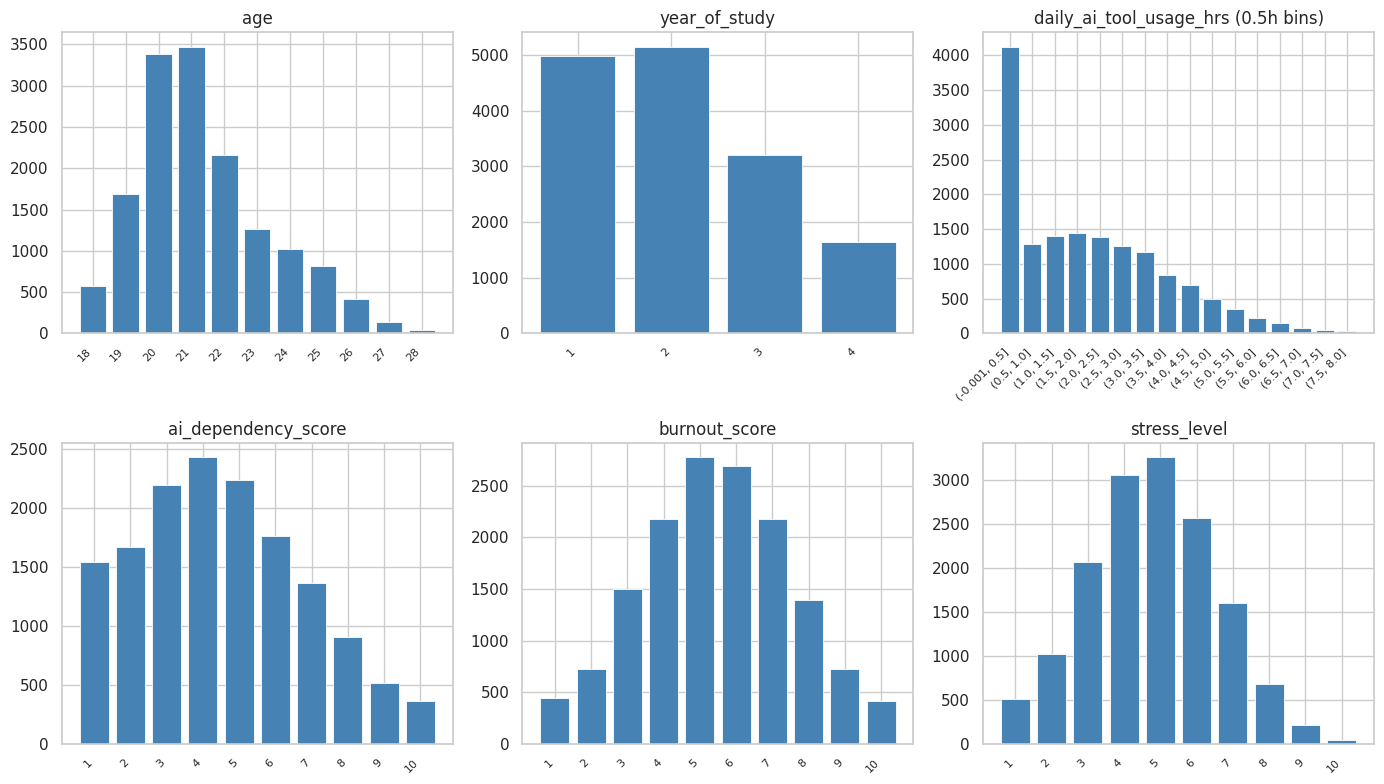

In [3]:
def _count_bar(ax, vc: pd.Series, title: str) -> None:
    x = np.arange(len(vc))
    ax.bar(x, vc.values, color="steelblue", edgecolor="white", linewidth=0.6)
    ax.set_xticks(x)
    ax.set_xticklabels([str(i) for i in vc.index], rotation=45, ha="right", fontsize=8)
    ax.set_title(title)


fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()
_count_bar(axes[0], df["age"].value_counts().sort_index(), "age")
_count_bar(axes[1], df["year_of_study"].value_counts().sort_index(), "year_of_study")
ai_bins = np.arange(0, 8.25, 0.5)
ai_binned = pd.cut(df["daily_ai_tool_usage_hrs"], bins=ai_bins, include_lowest=True)
_count_bar(axes[2], ai_binned.value_counts().sort_index(), "daily_ai_tool_usage_hrs (0.5h bins)")
_count_bar(axes[3], df["ai_dependency_score"].value_counts().sort_index(), "ai_dependency_score")
_count_bar(axes[4], df["burnout_score"].value_counts().sort_index(), "burnout_score")
_count_bar(axes[5], df["stress_level"].value_counts().sort_index(), "stress_level")
plt.tight_layout()
plt.show()



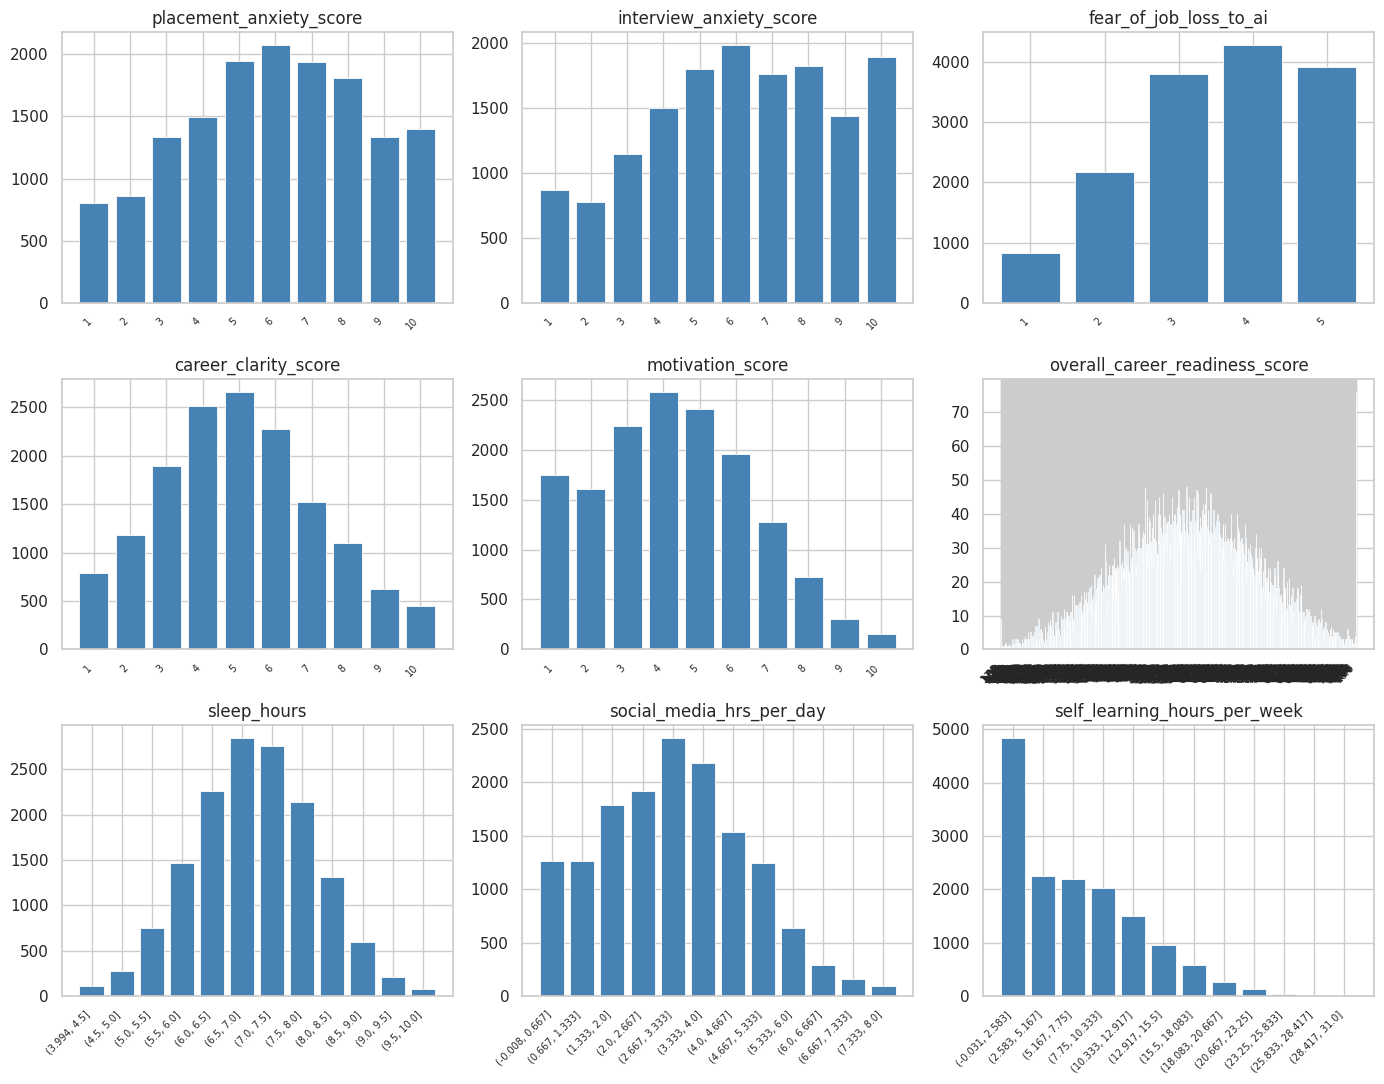

In [4]:
def _bar_col(ax, col: str) -> None:
    s = df[col]
    if col in ("sleep_hours", "social_media_hrs_per_day", "self_learning_hours_per_week"):
        s = pd.cut(s, bins=12)
    vc = s.value_counts().sort_index()
    x = np.arange(len(vc))
    ax.bar(x, vc.values, color="steelblue", edgecolor="white", linewidth=0.6)
    ax.set_xticks(x)
    ax.set_xticklabels([str(i) for i in vc.index], rotation=45, ha="right", fontsize=7)
    ax.set_title(col)


fig, axes = plt.subplots(3, 3, figsize=(14, 11))
axes = axes.flatten()
more_cols = [
    "placement_anxiety_score",
    "interview_anxiety_score",
    "fear_of_job_loss_to_ai",
    "career_clarity_score",
    "motivation_score",
    "overall_career_readiness_score",
    "sleep_hours",
    "social_media_hrs_per_day",
    "self_learning_hours_per_week",
]
for ax, c in zip(axes, more_cols):
    _bar_col(ax, c)
plt.tight_layout()
plt.show()


### Univariate readouts (descriptive)

- **AI usage hours** are right-skewed: many students report modest daily use, with a long tail toward heavy daily use—useful when stratifying outcomes by usage intensity.
- **Burnout / stress / dependency scores** are discrete Likert-style integers; **bar charts** of counts show concentration versus spread—subgroups in multivariate plots should be interpreted with that scale structure in mind.
- **Tool mix:** `primary_ai_tools_used` clusters on common tools plus long-tail labels—cross-tabs and boxplots below focus on frequent categories when cell counts allow.



## Multivariate analysis

1. Two categoricals → crosstab heatmap (normalized within row).
2. Numeric ↔ numeric → Pearson correlation heatmap on all non-ID numeric columns.
3. Categorical × numeric → boxplots of burnout and AI dependency by tool and stream; scatter with visualization-only regression line for daily AI hours vs burnout.
4. Three-way pattern → **gender × primary LLM provider × burnout** (boxplots on the top tools by usage).
5. Two numeric outcomes stratified → **placement anxiety vs interview anxiety** by **`gender` hue** on a **`sns.JointGrid`** (`scatterplot` joint + `histplot` marginals), with light jitter on discrete scores.
6. Correlation extremes → **top 5 strongest positive and top 5 strongest negative** pairwise Pearson correlations (excluding \|r\| ≈ 1), each shown as its own **`sns.JointGrid`** (`scatterplot`, `histplot`).



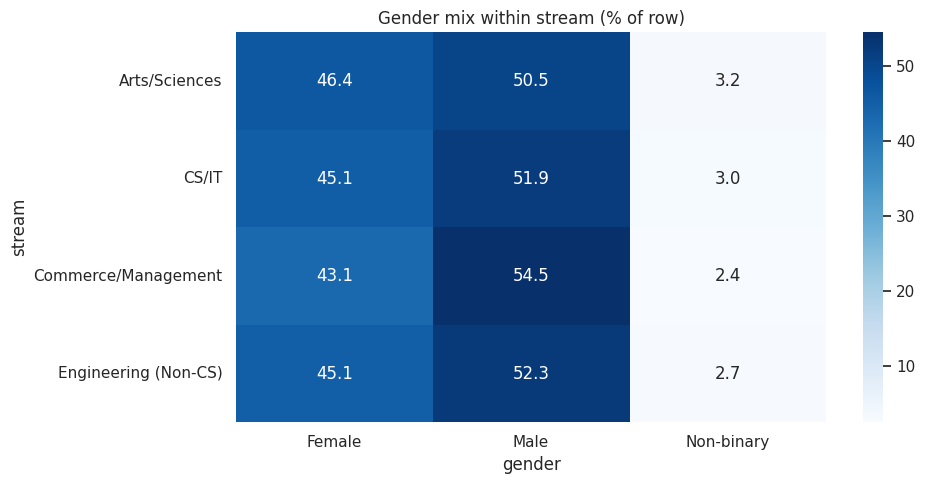

In [5]:
xt = pd.crosstab(df["stream"], df["gender"], normalize="index") * 100
plt.figure(figsize=(10, 5))
sns.heatmap(xt, annot=True, fmt=".1f", cmap="Blues")
plt.title("Gender mix within stream (% of row)")
plt.ylabel("stream")
plt.xlabel("gender")
plt.tight_layout()
plt.show()



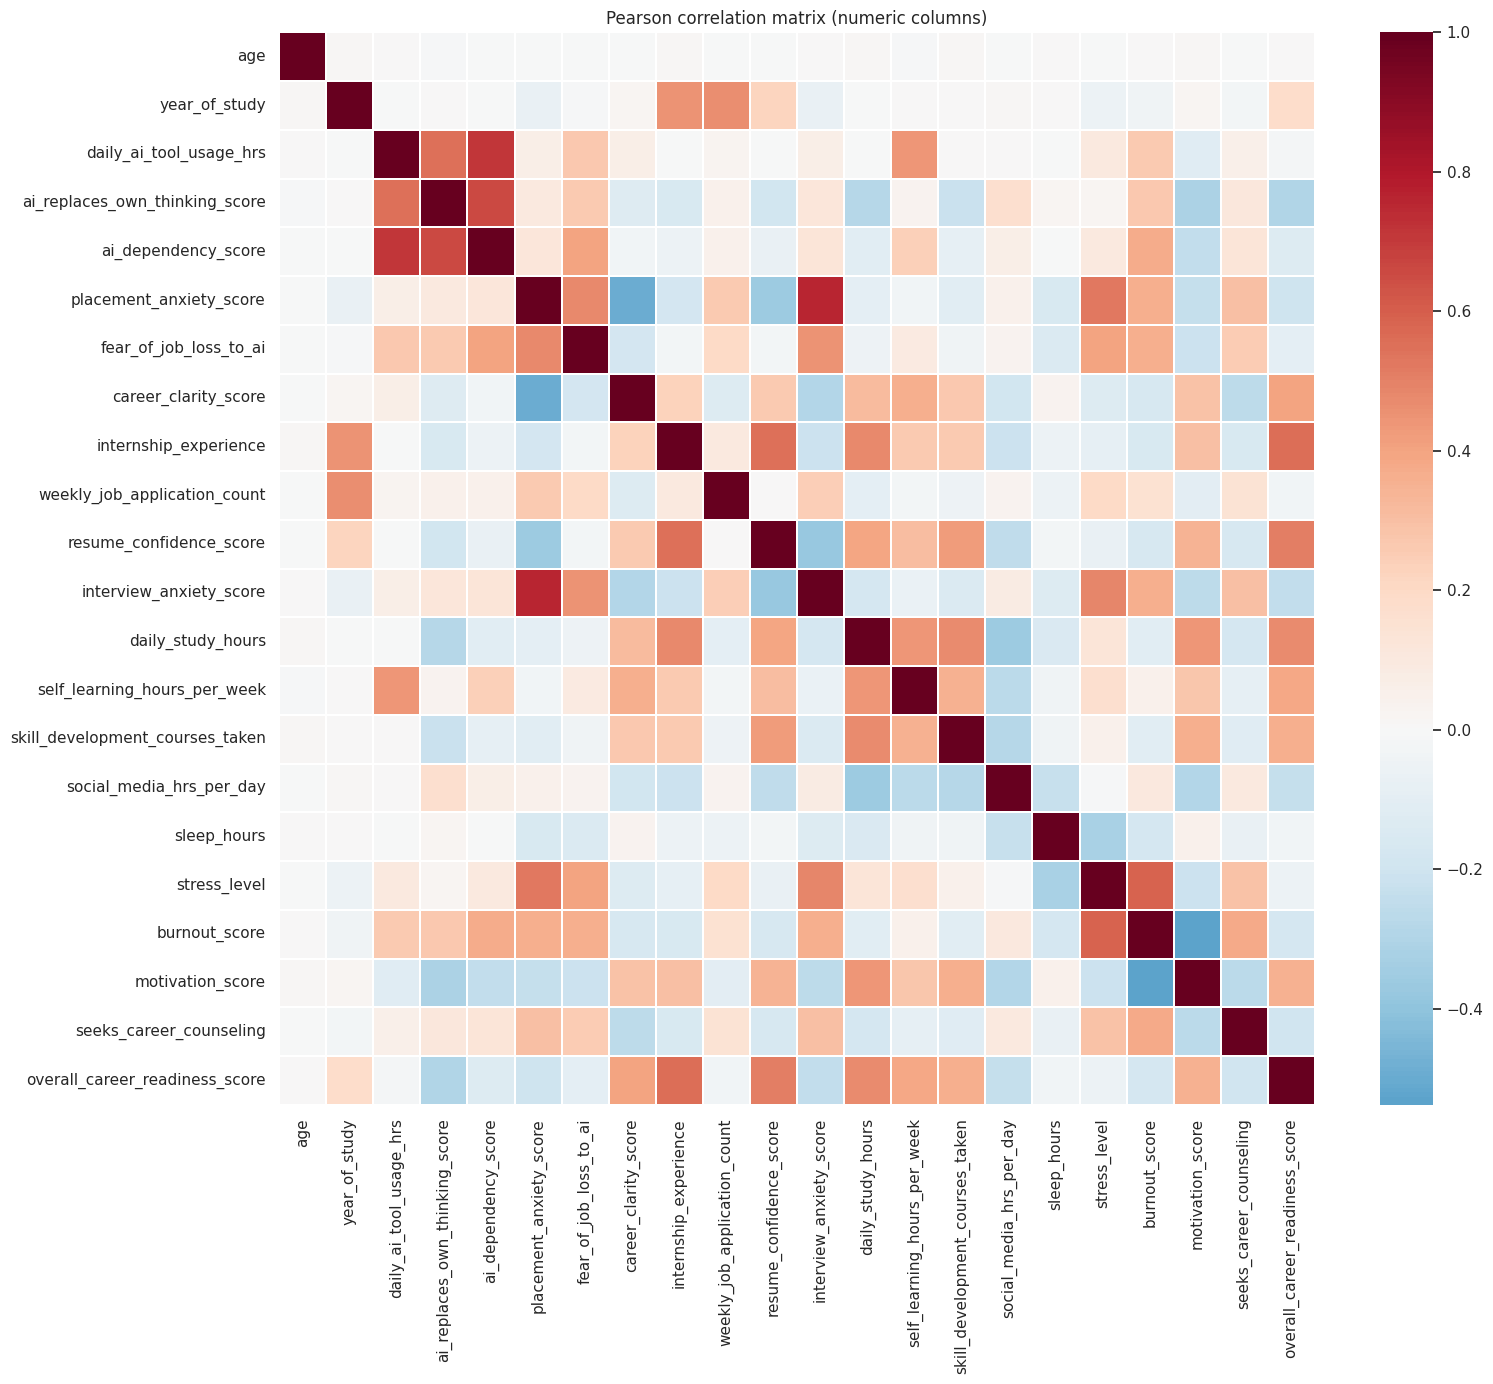

In [6]:
num_cols = [c for c in df.columns if c != "student_id" and pd.api.types.is_numeric_dtype(df[c])]
corr = df[num_cols].corr(method="pearson")
plt.figure(figsize=(16, 14))
sns.heatmap(corr, cmap="RdBu_r", center=0, annot=False, linewidths=0.2)
plt.title("Pearson correlation matrix (numeric columns)")
plt.tight_layout()
plt.show()



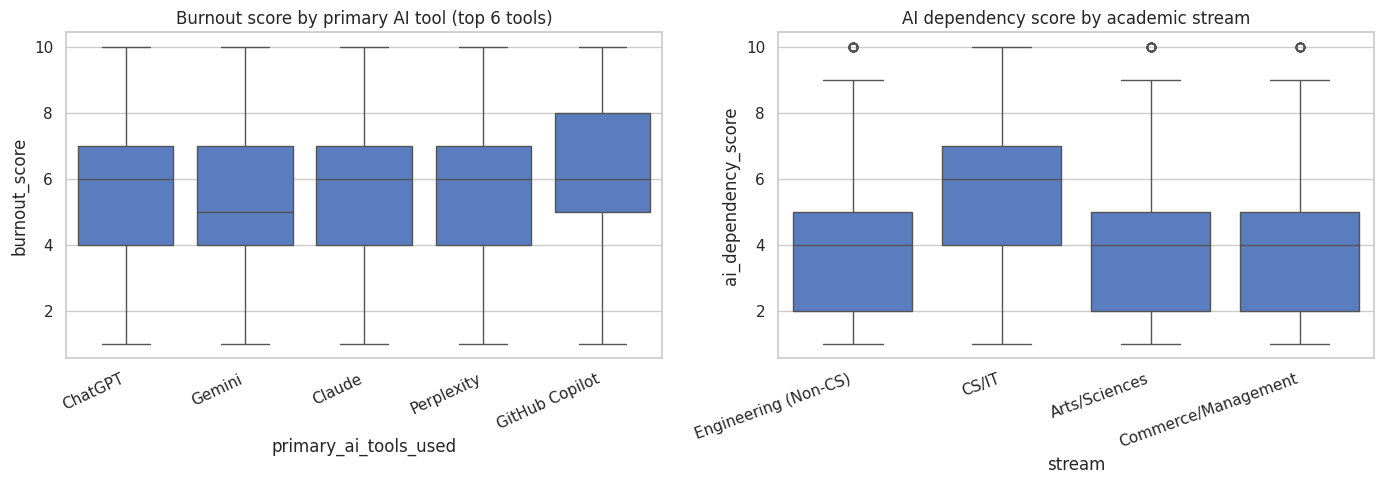

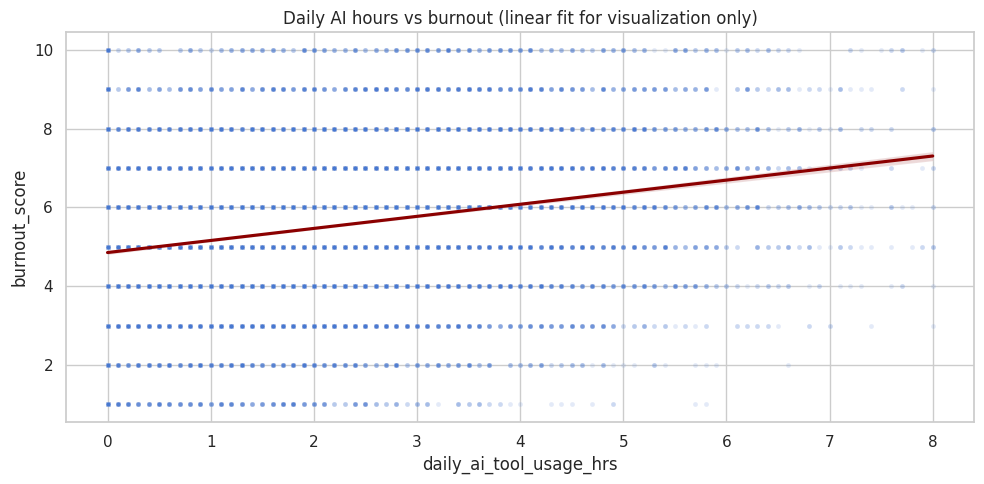

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
order_tools = df["primary_ai_tools_used"].value_counts().head(6).index.tolist()
sns.boxplot(data=df, x="primary_ai_tools_used", y="burnout_score", order=order_tools, ax=axes[0])
plt.setp(axes[0].get_xticklabels(), rotation=25, ha="right")
axes[0].set_title("Burnout score by primary AI tool (top 6 tools)")

sns.boxplot(data=df, x="stream", y="ai_dependency_score", ax=axes[1])
plt.setp(axes[1].get_xticklabels(), rotation=20, ha="right")
axes[1].set_title("AI dependency score by academic stream")

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
sns.scatterplot(
    data=df,
    x="daily_ai_tool_usage_hrs",
    y="burnout_score",
    alpha=0.15,
    s=12,
    ax=ax,
)
sns.regplot(
    data=df,
    x="daily_ai_tool_usage_hrs",
    y="burnout_score",
    scatter=False,
    color="darkred",
    ax=ax,
)
ax.set_title("Daily AI hours vs burnout (linear fit for visualization only)")
plt.tight_layout()
plt.show()



### Gender × LLM provider × burnout

Primary tool (`primary_ai_tools_used`) is restricted to the **top six** labels by frequency so cell sizes stay interpretable. Burnout is ordinal/Likert-style; boxplots show median and spread within each gender × tool bucket.



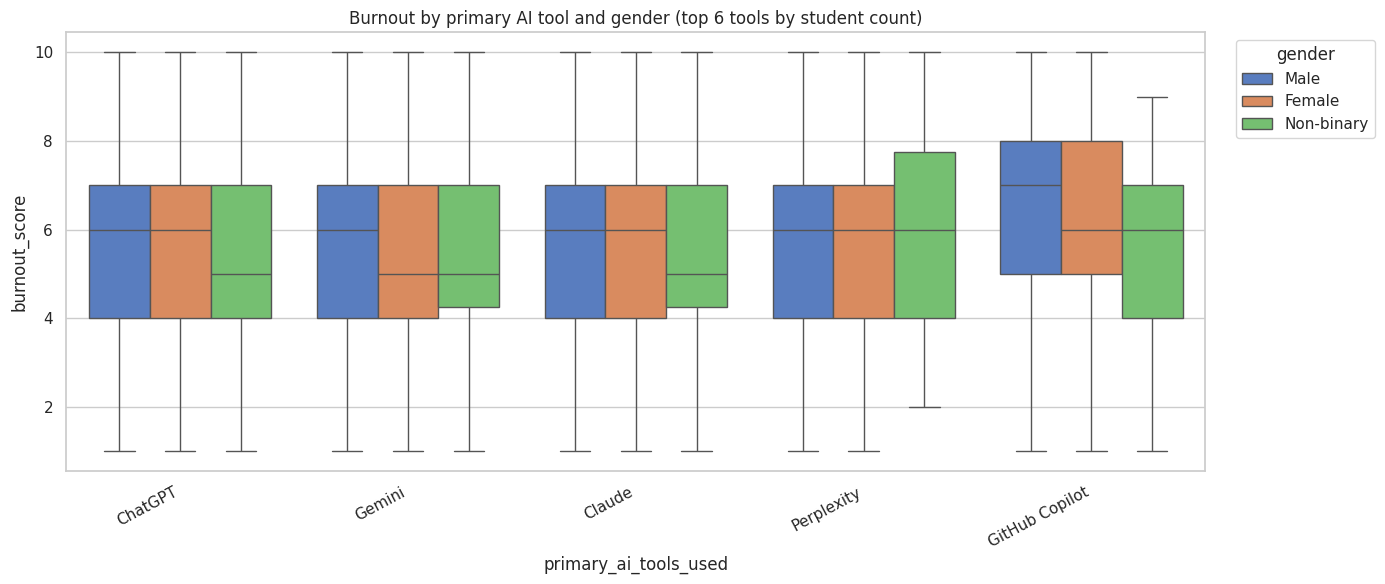

Mean / median burnout by gender × primary tool (top tools only):


,gender,primary_ai_tools_used,mean_burnout,median_burnout,n
0,Female,ChatGPT,5.627897,6.0,2416
5,Male,ChatGPT,5.612344,6.0,2884
10,Non-binary,ChatGPT,5.443787,5.0,169
1,Female,Claude,5.710556,6.0,881
6,Male,Claude,5.559252,6.0,962
11,Non-binary,Claude,5.700000,5.0,50
2,Female,Gemini,5.433333,5.0,1110
7,Male,Gemini,5.491215,6.0,1309
12,Non-binary,Gemini,5.629032,5.0,62
3,Female,GitHub Copilot,6.251799,6.0,417


In [8]:
TOP_TOOLS_N = 6
tool_order = df["primary_ai_tools_used"].value_counts().head(TOP_TOOLS_N).index.tolist()
df_tools = df[df["primary_ai_tools_used"].isin(tool_order)].copy()

plt.figure(figsize=(14, 6))
sns.boxplot(
    data=df_tools,
    x="primary_ai_tools_used",
    y="burnout_score",
    hue="gender",
    order=tool_order,
)
plt.xticks(rotation=28, ha="right")
plt.xlabel("primary_ai_tools_used")
plt.ylabel("burnout_score")
plt.title("Burnout by primary AI tool and gender (top 6 tools by student count)")
plt.legend(title="gender", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

by_gender_tool = (
    df_tools.groupby(["gender", "primary_ai_tools_used"], observed=True)["burnout_score"]
    .agg(mean_burnout="mean", median_burnout="median", n="count")
    .reset_index()
    .sort_values(["primary_ai_tools_used", "gender"])
)
print("Mean / median burnout by gender × primary tool (top tools only):")
display(by_gender_tool)

